In [1]:
import scanpy as sc
import pandas as pd
import numpy as nu
from scipy.sparse import csr_matrix

from matplotlib import pyplot as plt
from matplotlib import rcParams
%matplotlib inline

##import Spatial Cell ID libraries
#import SpatialCellID as SCID

#for data integration
import scanorama

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=200, facecolor='white')

2023-02-28 16:53:58.360276: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.21.5 scipy==1.7.3 pandas==1.3.5 scikit-learn==1.0.2 statsmodels==0.13.5 python-igraph==0.9.10 pynndescent==0.5.8


In [3]:
adata = sc.read_h5ad("/home/ssarnataro/Work/Camille/python_analysis_from_scratch/adata_adjusted_with_scanorama.h5ad")

In [4]:
sc.pp.highly_variable_genes(adata, n_top_genes=3000, flavor="cell_ranger", batch_key='sample')

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:03)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [5]:
sc.tl.leiden(adata, key_added="leiden", resolution=0.5)

running Leiden clustering
    finished: found 16 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:04)


In [8]:
clustering_algorithm = 'leiden'

In [9]:
clustering_name = clustering_algorithm 
label_name = '1'
cells_name = adata.obs[clustering_name].loc[adata.obs[clustering_name] == label_name].index
cells_indices = adata.obs.reset_index().loc[adata.obs.reset_index()['index'].isin(cells_name)].index.values
coordinates_cluster = adata.X[cells_indices]

In [38]:
# def clustering_score(original_adata, clustering_algorithm='leiden', min_res=0.05, max_res=2.0, step=0.05, metrics='BIC', plot=False, bic_coordinates='gene_expression'):
    
#     import numpy as np
#     from sklearn.cluster import KMeans

#     sc.settings.verbosity = 0

#     res = list(nu.arange(min_res,max_res,step))
#     score = []
#     n_clus = []



#     if metrics == 'BIC':

#         for r in res:
#             index = res.index(r)
#             adata = original_adata.copy()
#             string_r = str(r)

#             print('Clustering by using the resolution %.2f, step %i of %i' %(r,index+1,len(res)))
            
#             if clustering_algorithm == 'leiden':
#                 clustering_name = '%s_res%s' %(clustering_algorithm,string_r)
#                 sc.tl.leiden(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)
#             else:
#                 print('Sorry, we only implemented the leiden algorithm so far. Please set clustering_algorithm="leiden"' )

#             n_points = len(adata.obs[clustering_name])
#             n_clusters = len(set(adata.obs[clustering_name]))
            
#             labels = [int(i) for i in adata.obs[clustering_name].values]
            
#             if bic_coordinates == 'gene_expression':
#                 n_dimensions = nu.shape(adata.X)[1]
#             elif bic_coordinates == 'X_umap':
#                 dim_reduction = 'X_umap'
#                 n_dimensions = adata.obsm[dim_reduction].shape[1]

#             n_parameters = (n_clusters - 1) + (n_dimensions * n_clusters) + 1
            
#              # calculate the center of each cluster by using kmeans approximation
#             if bic_coordinates == 'gene_expression':
#                 kmeans = Kmeans(n_clusters=n_clusters).fit(adata.X)
#             elif bic_coordinates == 'X_umap':
#                 kmeans = Kmeans(n_clusters=n_clusters).fit(adata.obsm[dim_reduction][cells_indices])
#             centers = kmeans.cluster_centers_
            
#             loglikelihood = np.sum(np.log(np.exp(-0.5 * np.sum((coordinates_cluster - medoids[labels])**2, axis=1)) / np.sqrt(2 * np.pi)))
           
#             bic = -2*loglikelihood + np.log(n_points_cluster)

#             score.append(bic)
#             n_clus.append(n_clusters)

#             del adata.obs[clustering_name]

#         df = pd.DataFrame()
#         df['score'] = score
#         df['resolution'] = res
#         df['n_clus'] = n_clus

#         if plot==True:
#             df.plot(x='resolution',y='score')
#         print('\n')

#     else:
#         print('Sorry, only BIC metrics has been implemented so far')

#     return df, res[nu.argmax(score)]

In [5]:
def clustering_score(original_adata, clustering_algorithm='leiden', min_res=0.05, max_res=2.0, step=0.05, metrics='BIC', plot=False, bic_coordinates='gene_expression'):
    
    import numpy as np
#     from scipy.spatial.distance import euclidean
#     from scipy.stats import median_abs_deviation
    
    sc.settings.verbosity = 0

    res = list(nu.arange(min_res,max_res,step))
    score = []
    n_clus = []



    if metrics == 'BIC':

        for r in res:
            index = res.index(r)
            adata = original_adata.copy()
            string_r = str(r)
            clustering_name = '%s_res%s' %(clustering_algorithm,string_r)
            print('Clustering by using the resolution %.2f, step %i of %i' %(r,index+1,len(res)))
            sc.tl.leiden(adata, key_added="%s_res%s" %(clustering_algorithm,string_r), resolution=r)

            n_points = len(adata.obs[clustering_name])
            n_clusters = len(set(adata.obs[clustering_name]))
            if bic_coordinates == 'gene_expression':
                n_dimensions = nu.shape(adata.X)[1]
            elif bic_coordinates == 'X_umap':
                dim_reduction = 'X_umap'
                n_dimensions = adata.obsm[dim_reduction].shape[1]

            n_parameters = (n_clusters - 1) + (n_dimensions * n_clusters) + 1

            loglikelihood = 0

            for label_name in set(adata.obs[clustering_name]):
                cells_name = adata.obs[clustering_name].loc[adata.obs[clustering_name] == label_name].index
                cells_indices = adata.obs.reset_index().loc[adata.obs.reset_index()['index'].isin(cells_name)].index.values
                n_points_cluster = len(cells_name)
            
                if bic_coordinates == 'gene_expression':
                    coordinates_cluster = adata.X[cells_indices]
                elif bic_coordinates == 'X_umap':
                    coordinates_cluster = adata.obsm[dim_reduction][cells_indices]
                    
                centroid = nu.mean(coordinates_cluster, axis = 0)
                variance = nu.sum((coordinates_cluster - centroid) ** 2) / (len(cells_name) - 1)
                
                loglikelihood += n_points_cluster * nu.log(n_points_cluster) \
                - n_points_cluster * nu.log(n_points) \
                - n_points_cluster * n_dimensions / 2 * nu.log(2 * 3.141592653589793 * variance) \
                - (n_points_cluster - 1) / 2

#                 centroid = nu.median(coordinates_cluster, axis = 0)
#                 variance = nu.sum(nu.square(median_abs_deviation(coordinates_cluster - centroid, axis=0, scale = 'normal')**2))
        
#                 loglikelihood += n_points_cluster * nu.log(n_points_cluster) \
#                 - n_points_cluster * nu.log(n_points) \
#                 - n_points_cluster * n_dimensions / 2 * nu.log(2 * 3.141592653589793 * variance) \
#                 - (n_points_cluster - 1) / 2

            bic = loglikelihood - (n_parameters / 2) * nu.log(n_points)

            score.append(bic)
            n_clus.append(n_clusters)

            del adata.obs[clustering_name]

        df = pd.DataFrame()
        df['score'] = score
        df['resolution'] = res
        df['n_clus'] = n_clus

        if plot==True:
            df.plot(x='resolution',y='score')
        print('\n')

    else:
        print('Sorry, only BIC metrics has been implemented so far')

    return df, res[nu.argmax(score)]


Clustering by using the resolution 0.10, step 1 of 9
Clustering by using the resolution 0.20, step 2 of 9
Clustering by using the resolution 0.30, step 3 of 9
Clustering by using the resolution 0.40, step 4 of 9
Clustering by using the resolution 0.50, step 5 of 9
Clustering by using the resolution 0.60, step 6 of 9
Clustering by using the resolution 0.70, step 7 of 9
Clustering by using the resolution 0.80, step 8 of 9
Clustering by using the resolution 0.90, step 9 of 9




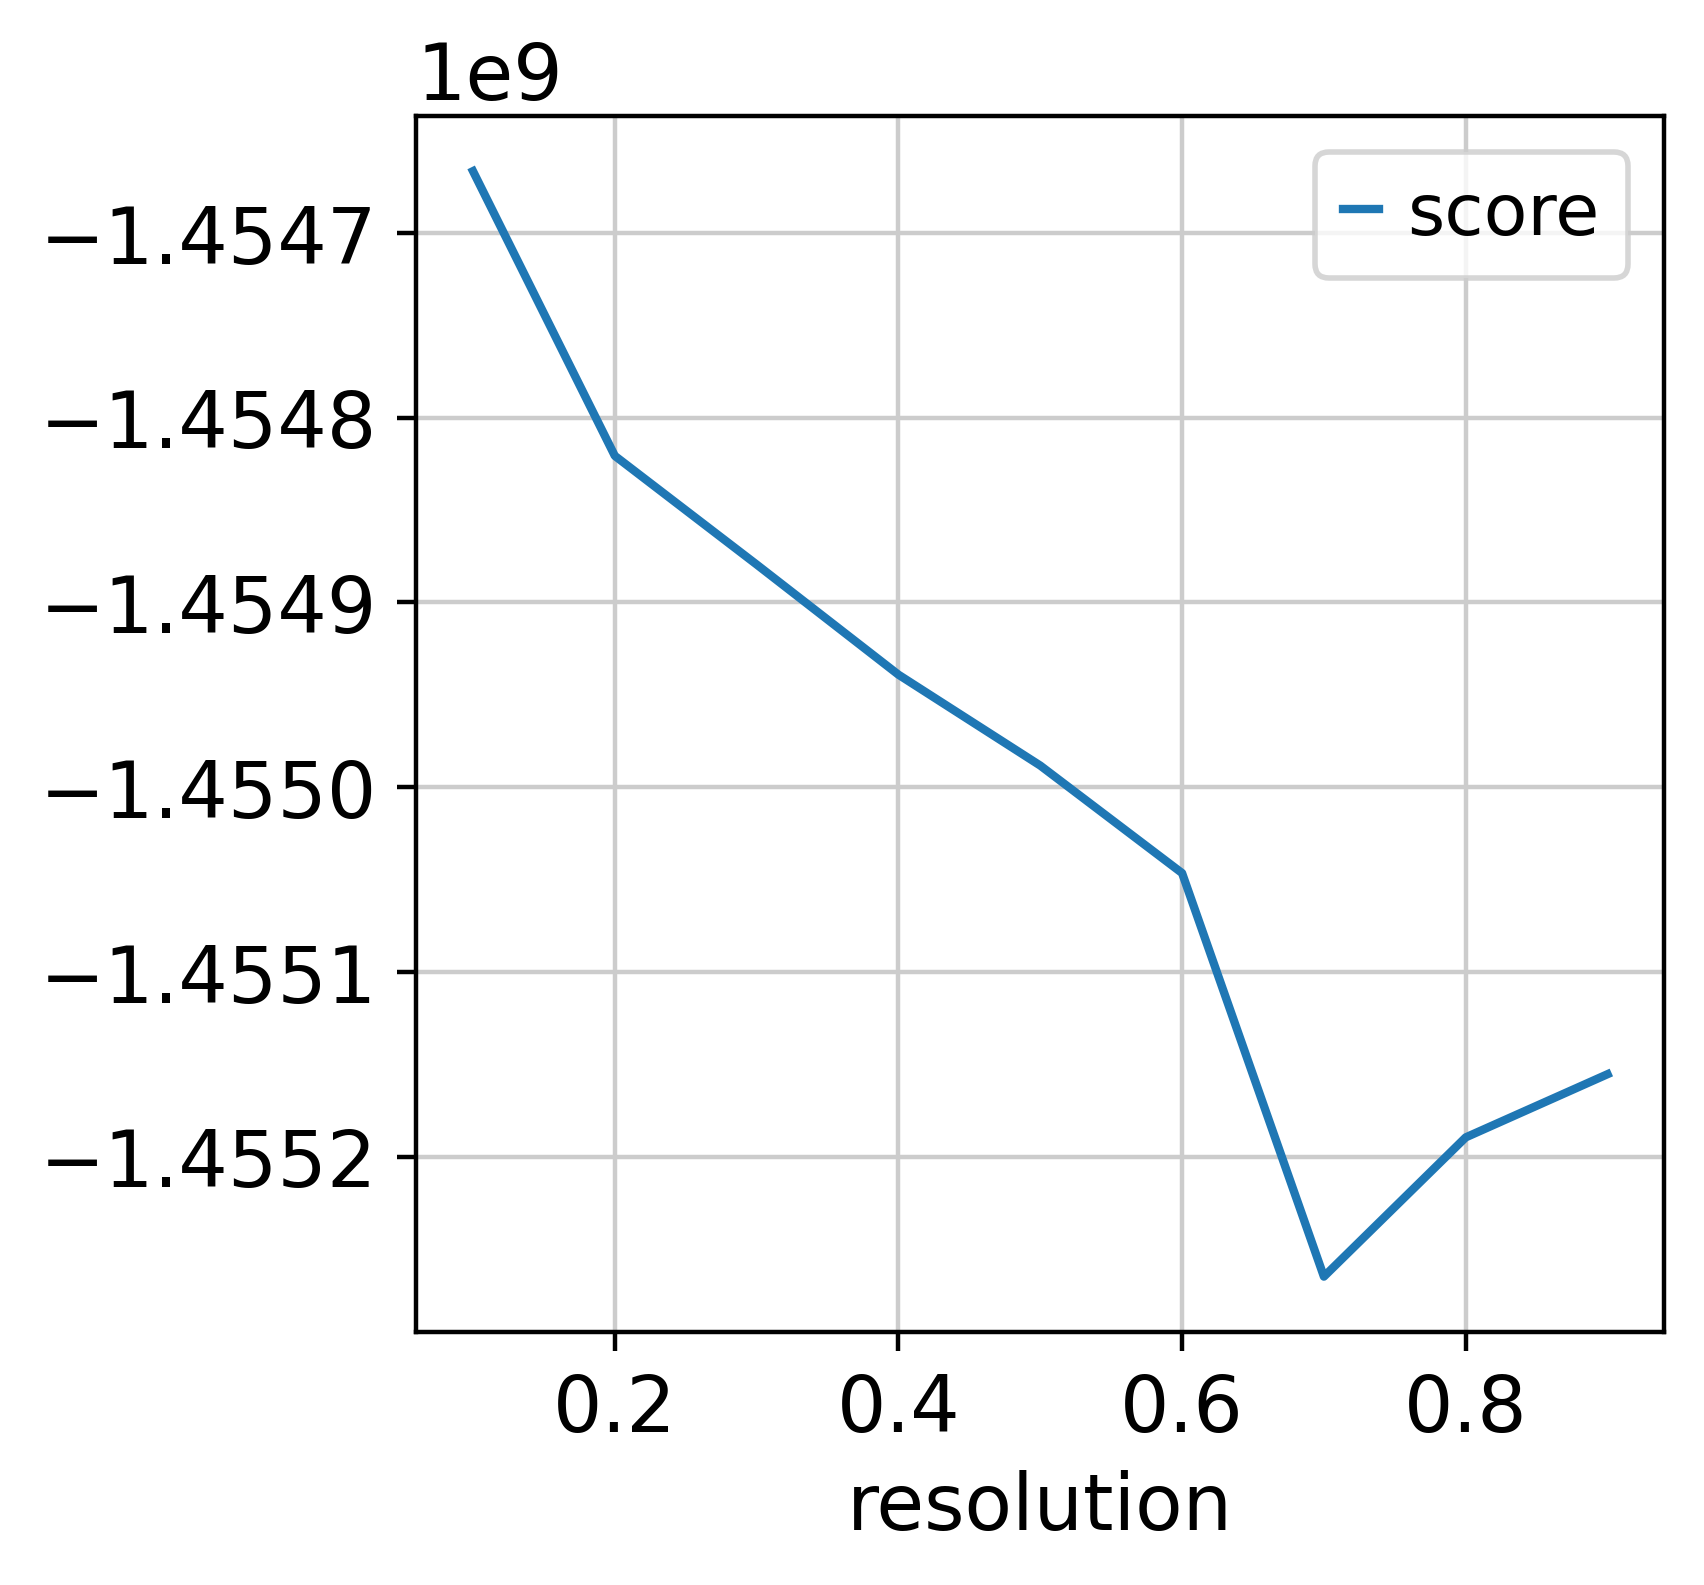

In [16]:
a = clustering_score(adata, min_res=0.1,max_res=1.0,step=0.1, plot=True, bic_coordinates='gene_expression')

Clustering by using the resolution 0.10, step 1 of 9
Clustering by using the resolution 0.20, step 2 of 9
Clustering by using the resolution 0.30, step 3 of 9
Clustering by using the resolution 0.40, step 4 of 9
Clustering by using the resolution 0.50, step 5 of 9
Clustering by using the resolution 0.60, step 6 of 9
Clustering by using the resolution 0.70, step 7 of 9
Clustering by using the resolution 0.80, step 8 of 9
Clustering by using the resolution 0.90, step 9 of 9




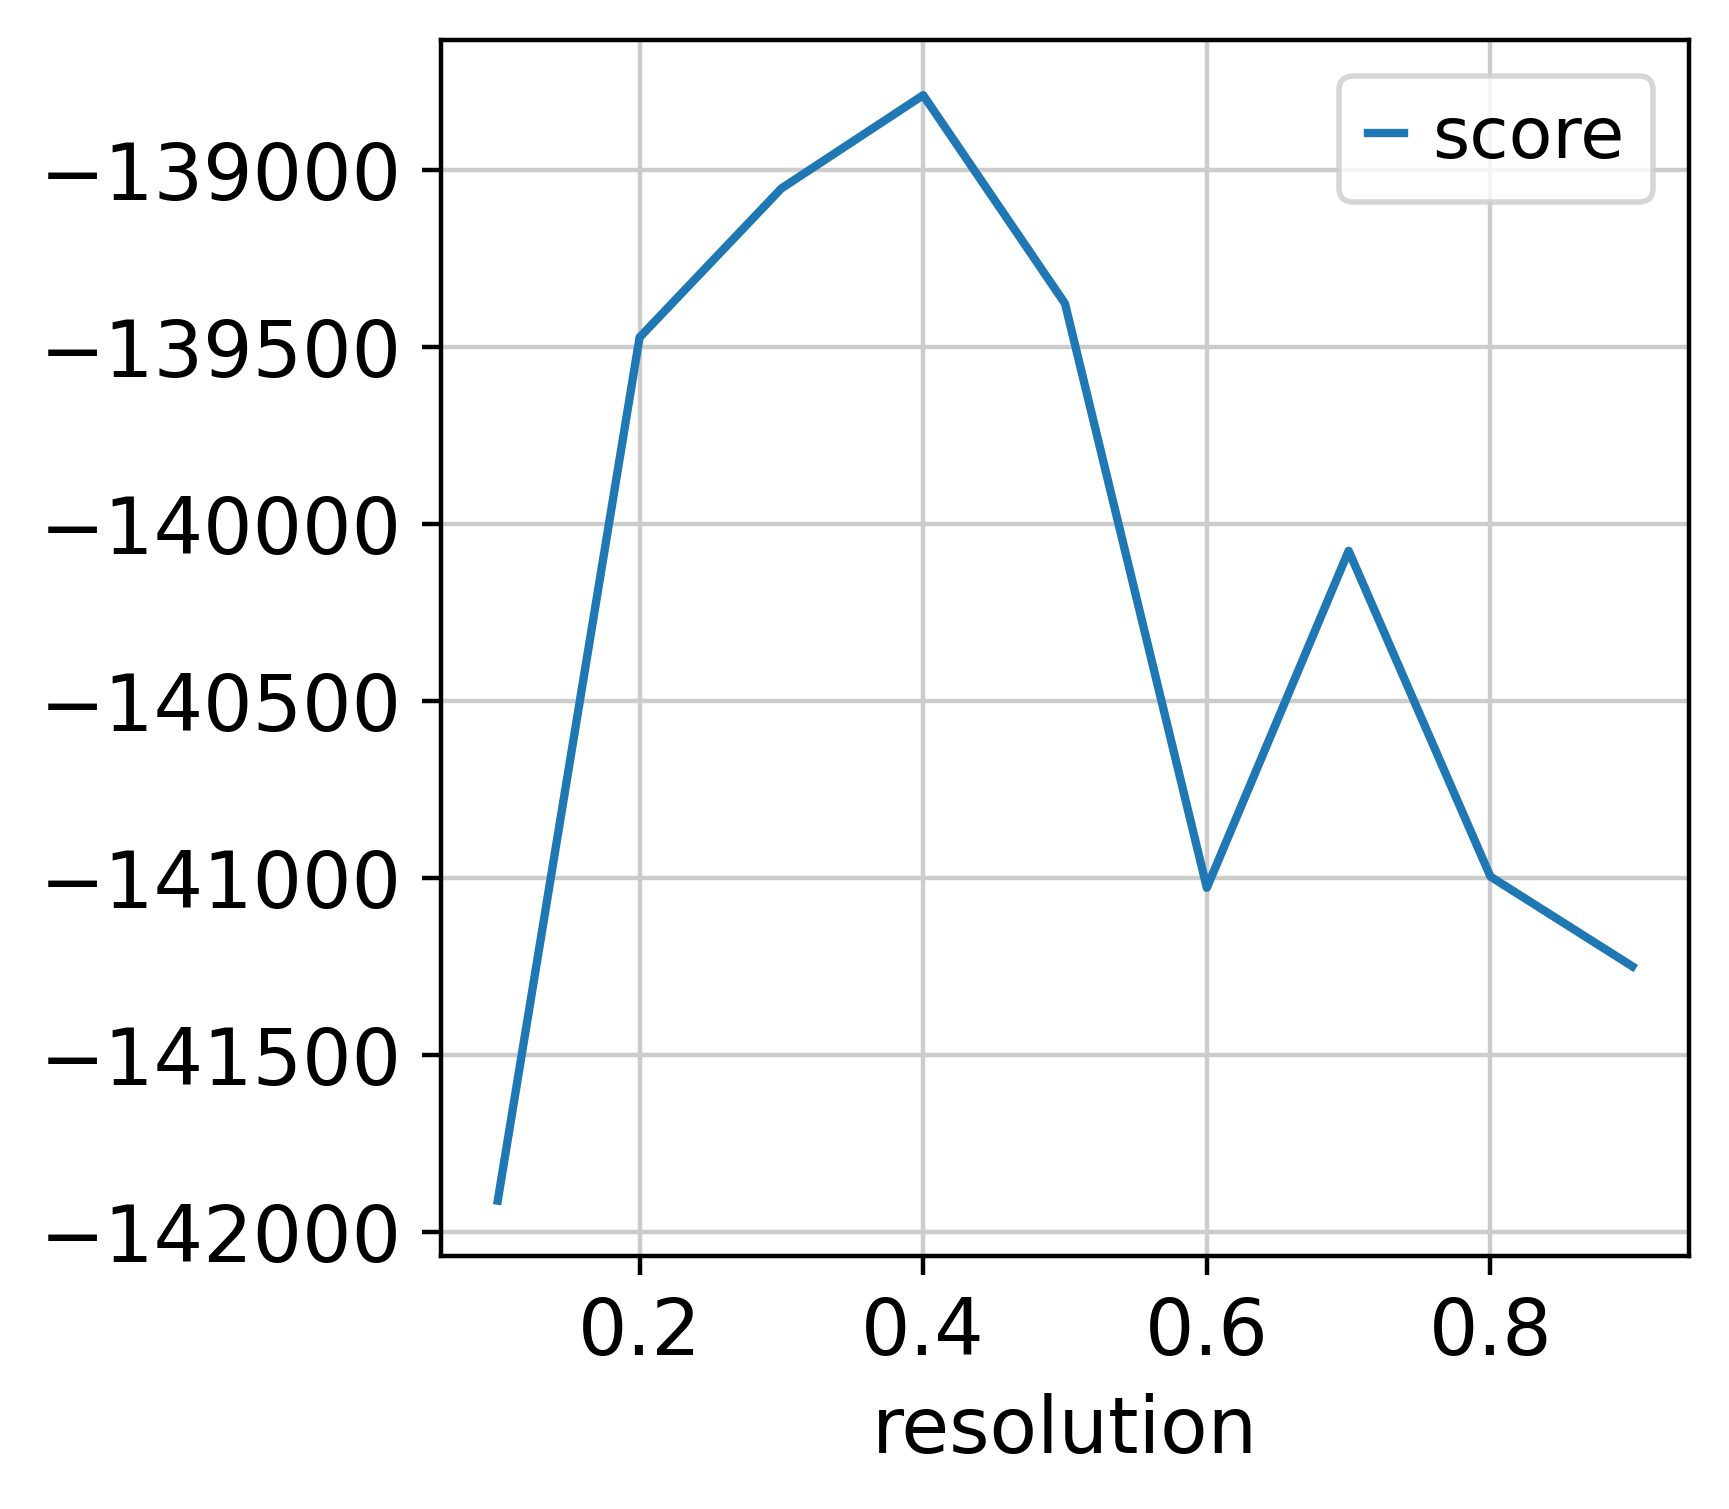

In [6]:
a = clustering_score(adata, min_res=0.1,max_res=1.0,step=0.1, plot=True, bic_coordinates='X_umap')

In [7]:
a[0]

,score,resolution,n_clus
0,-193042.027997,0.1,6
1,-188342.162258,0.2,10
2,-188181.191362,0.3,11
3,-186457.346296,0.4,15
4,-187538.730490,0.5,16
5,-189274.358169,0.6,17
6,-189136.494276,0.7,19
7,-193430.808254,0.8,19
8,-192552.872478,0.9,22
